## Install Required Libraries

In [1]:
!pip install -q segmentation-models-pytorch==0.5.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 99.0 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cudf-cu12

In [2]:
import torch
import segmentation_models_pytorch as smp
import albumentations as A

print("Torch:", torch.__version__)
print("SMP:", smp.__version__)
print("Albumentations:", A.__version__)

Torch: 2.10.0+cu128
SMP: 0.5.0
Albumentations: 2.0.8


## Imports

In [3]:
import os
import cv2
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import Dataset
from torch.utils.data import DataLoader

import torchvision.transforms as T

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

from sklearn.utils.class_weight import compute_class_weight

from sklearn.metrics import confusion_matrix

import warnings
warnings.filterwarnings("ignore")

## GPU Verification

In [4]:
print("CUDA Available:", torch.cuda.is_available())

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

CUDA Available: True
Device: cuda
GPU: Tesla T4


## Reproducibility

In [5]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

## Dataset Paths

In [6]:
DATASET_DIR = (
    "/kaggle/input/datasets/neeldaiict/xbd-tier3-preprocessed"
)

train_csv = os.path.join(
    DATASET_DIR,
    "train_masks.csv"
)

val_csv = os.path.join(
    DATASET_DIR,
    "val_masks.csv"
)

test_csv = os.path.join(
    DATASET_DIR,
    "test_masks.csv"
)

## Loading CSV Files

In [7]:
train_df = pd.read_csv(train_csv)

val_df = pd.read_csv(val_csv)

test_df = pd.read_csv(test_csv)

print("Train:", len(train_df))
print("Validation:", len(val_df))
print("Test:", len(test_df))

Train: 4458
Validation: 955
Test: 956


## Fixing Mask Paths

In [8]:
MASK_ROOT = os.path.join(
    DATASET_DIR,
    "processed_masks"
)

def fix_mask_path(relative_path):

    relative_path = relative_path.replace(
        "processed_masks/",
        ""
    )

    return os.path.join(
        MASK_ROOT,
        relative_path
    )

train_df["mask_path"] = (
    train_df["mask_path"]
    .apply(fix_mask_path)
)

val_df["mask_path"] = (
    val_df["mask_path"]
    .apply(fix_mask_path)
)

test_df["mask_path"] = (
    test_df["mask_path"]
    .apply(fix_mask_path)
)

## Verifying Dataset Paths

In [9]:
sample = train_df.iloc[0]

print(sample["pre_image"])
print()

print(sample["post_image"])
print()

print(sample["mask_path"])
print()

print(
    "Mask Exists:",
    os.path.exists(
        sample["mask_path"]
    )
)

/kaggle/input/datasets/tunguz/xview2-challenge-dataset-tier-3-data/tier3/images/sunda-tsunami_00000085_pre_disaster.png

/kaggle/input/datasets/tunguz/xview2-challenge-dataset-tier-3-data/tier3/images/sunda-tsunami_00000085_post_disaster.png

/kaggle/input/datasets/neeldaiict/xbd-tier3-preprocessed/processed_masks/train/sunda-tsunami_00000085_post_disaster_mask.png

Mask Exists: True


## Damage Classes

In [10]:
CLASS_NAMES = {
    0: "Background",
    1: "No Damage",
    2: "Minor Damage",
    3: "Major Damage",
    4: "Destroyed"
}

NUM_CLASSES = 5

print(CLASS_NAMES)

{0: 'Background', 1: 'No Damage', 2: 'Minor Damage', 3: 'Major Damage', 4: 'Destroyed'}


## Image Augmentations

In [11]:
IMAGE_SIZE = 256

In [12]:
# training transform
train_transform = A.Compose([
    
    A.HorizontalFlip(p=0.5),

    A.VerticalFlip(p=0.5),

    A.RandomRotate90(p=0.5),

    A.Normalize(),

    ToTensorV2()
])

In [13]:
# validation transform
val_transform = A.Compose([

    A.Normalize(),

    ToTensorV2()
])

## xBD Dataset Class

In [14]:
class XBDDataset(Dataset):

    def __init__(
        self,
        dataframe,
        transform=None
    ):

        self.df = dataframe.reset_index(
            drop=True
        )

        self.transform = transform

    def __len__(self):

        return len(self.df)

    def __getitem__(self, idx):

        row = self.df.iloc[idx]

        pre_img = np.array(
            Image.open(
                row["pre_image"]
            ).convert("RGB")
        )

        post_img = np.array(
            Image.open(
                row["post_image"]
            ).convert("RGB")
        )

        mask = np.array(
            Image.open(
                row["mask_path"]
            )
        )

        pre_img = cv2.resize(
            pre_img,
            (IMAGE_SIZE, IMAGE_SIZE)
        )

        post_img = cv2.resize(
            post_img,
            (IMAGE_SIZE, IMAGE_SIZE)
        )

        mask = cv2.resize(
            mask,
            (IMAGE_SIZE, IMAGE_SIZE),
            interpolation=cv2.INTER_NEAREST
        )

        six_channel = np.concatenate(
            [pre_img, post_img],
            axis=2
        )

        if self.transform:

            transformed = self.transform(
                image=six_channel,
                mask=mask
            )

            six_channel = transformed["image"]

            mask = transformed["mask"]

        return (
            six_channel.float(),
            mask.long()
        )

## Create Dataset Objects

In [15]:
train_dataset = XBDDataset(
    train_df,
    transform=train_transform
)

val_dataset = XBDDataset(
    val_df,
    transform=val_transform
)

test_dataset = XBDDataset(
    test_df,
    transform=val_transform
)

## Create DataLoaders

In [16]:
BATCH_SIZE = 8

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print(
    "Train Batches:",
    len(train_loader)
)

print(
    "Validation Batches:",
    len(val_loader)
)

print(
    "Test Batches:",
    len(test_loader)
)

Train Batches: 558
Validation Batches: 120
Test Batches: 120


## Verify DataLoader Output

In [17]:
images, masks = next(
    iter(train_loader)
)

print(
    "Images Shape:",
    images.shape
)

print(
    "Masks Shape:",
    masks.shape
)

Images Shape: torch.Size([8, 6, 256, 256])
Masks Shape: torch.Size([8, 256, 256])


## Visual Verification

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.0494049..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466563..2.2489083].


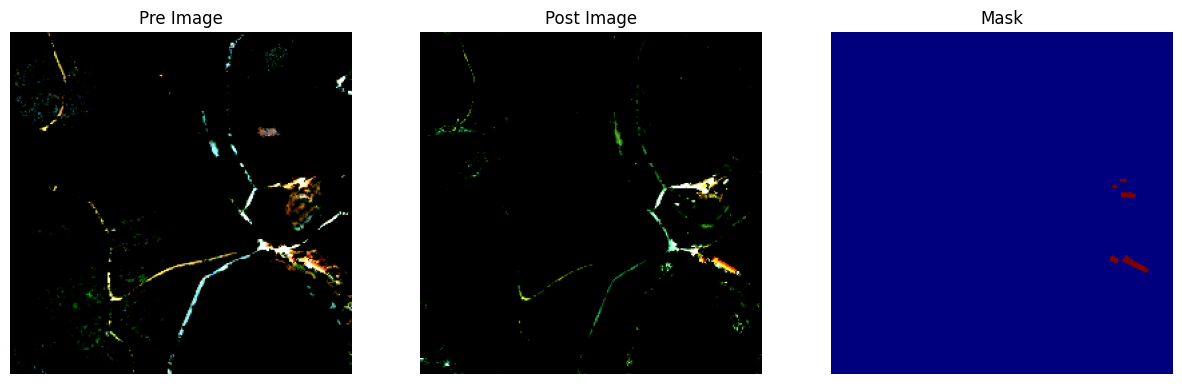

In [18]:
sample_img = images[0]

sample_mask = masks[0]

pre_img = (
    sample_img[:3]
    .permute(1,2,0)
    .cpu()
    .numpy()
)

post_img = (
    sample_img[3:]
    .permute(1,2,0)
    .cpu()
    .numpy()
)

plt.figure(figsize=(15,5))

plt.subplot(1,3,1)
plt.imshow(pre_img)
plt.title("Pre Image")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(post_img)
plt.title("Post Image")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(
    sample_mask.cpu().numpy(),
    cmap="jet"
)
plt.title("Mask")
plt.axis("off")

plt.show()

## Compute Class Weights

The xBD dataset is extremely imbalanced.

We use inverse-frequency weighting so the model does not learn to predict only background.

In [19]:
pixel_counts = {
    0: 410469786,
    1: 5564167,
    2: 540478,
    3: 347612,
    4: 476741
}

total_pixels = sum(pixel_counts.values())

class_weights = []

for cls in range(NUM_CLASSES):

    freq = pixel_counts[cls] / total_pixels

    weight = 1.0 / (freq + 1e-8)

    class_weights.append(weight)

class_weights = np.array(class_weights)

class_weights = (
    class_weights /
    class_weights.sum()
) * NUM_CLASSES

class_weights = torch.tensor(
    class_weights,
    dtype=torch.float32
).to(DEVICE)

print("Class Weights:")
print(class_weights)

Class Weights:
tensor([1.7385e-03, 1.2825e-01, 1.3203e+00, 2.0529e+00, 1.4968e+00],
       device='cuda:0')


## Multi-class Dice Loss

In [20]:
class DiceLoss(nn.Module):

    def __init__(
        self,
        smooth=1e-6
    ):
        super().__init__()

        self.smooth = smooth

    def forward(
        self,
        logits,
        targets
    ):

        probs = torch.softmax(
            logits,
            dim=1
        )

        targets_one_hot = torch.nn.functional.one_hot(
            targets,
            NUM_CLASSES
        )

        targets_one_hot = (
            targets_one_hot
            .permute(0,3,1,2)
            .float()
        )

        intersection = (
            probs *
            targets_one_hot
        ).sum((0,2,3))

        union = (
            probs +
            targets_one_hot
        ).sum((0,2,3))

        dice = (
            2.0 * intersection +
            self.smooth
        ) / (
            union +
            self.smooth
        )

        return 1.0 - dice.mean()

## Combined Loss (Weighted Cross Entropy + Dice Loss)

In [21]:
ce_loss = nn.CrossEntropyLoss(
    weight=class_weights
)

dice_loss = DiceLoss()

In [22]:
# combined loss function
def combined_loss(
    logits,
    targets
):

    ce = ce_loss(
        logits,
        targets
    )

    dice = dice_loss(
        logits,
        targets
    )

    return (
        0.5 * ce +
        0.5 * dice
    )

## SMP U-Net

Encoder:
ResNet34

Input Channels:
6 (Pre + Post)

Output Classes:
5

In [23]:
model = smp.Unet(

    encoder_name="resnet34",

    encoder_weights="imagenet",

    in_channels=6,

    classes=NUM_CLASSES

)

model = model.to(DEVICE)

print(
    "Model created successfully"
)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Model created successfully


## Model Parameters

In [24]:
total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total Parameters: {total_params:,}"
)

print(
    f"Trainable Parameters: {trainable_params:,}"
)

Total Parameters: 24,446,357
Trainable Parameters: 24,446,357


## Forward Pass Verification

In [25]:
images, masks = next(
    iter(train_loader)
)

images = images.to(DEVICE)

with torch.no_grad():

    outputs = model(images)

print(
    "Input Shape:",
    images.shape
)

print(
    "Output Shape:",
    outputs.shape
)

Input Shape: torch.Size([8, 6, 256, 256])
Output Shape: torch.Size([8, 5, 256, 256])


## Mean IoU Metric

In [26]:
def calculate_iou(
    preds,
    targets,
    num_classes=NUM_CLASSES
):

    preds = torch.argmax(
        preds,
        dim=1
    )

    ious = []

    for cls in range(num_classes):

        pred_inds = (
            preds == cls
        )

        target_inds = (
            targets == cls
        )

        intersection = (
            pred_inds &
            target_inds
        ).sum().item()

        union = (
            pred_inds |
            target_inds
        ).sum().item()

        if union == 0:
            continue

        ious.append(
            intersection / union
        )

    if len(ious) == 0:
        return 0.0

    return np.mean(ious)

## Dice Score Metric

In [27]:
def calculate_dice(
    preds,
    targets,
    num_classes=NUM_CLASSES
):

    preds = torch.argmax(
        preds,
        dim=1
    )

    scores = []

    for cls in range(num_classes):

        pred_inds = (
            preds == cls
        )

        target_inds = (
            targets == cls
        )

        intersection = (
            pred_inds &
            target_inds
        ).sum().item()

        total = (
            pred_inds.sum().item() +
            target_inds.sum().item()
        )

        if total == 0:
            continue

        dice = (
            2 * intersection
        ) / total

        scores.append(dice)

    if len(scores) == 0:
        return 0.0

    return np.mean(scores)

## Optimizer

In [28]:
optimizer = optim.AdamW(

    model.parameters(),

    lr=1e-4,

    weight_decay=1e-4
)

## Learning Rate Scheduler

In [29]:
scheduler = optim.lr_scheduler.ReduceLROnPlateau(

    optimizer,

    mode="min",

    factor=0.5,

    patience=2
)

## Automatic Mixed Precision (AMP)

In [30]:
scaler = torch.amp.GradScaler(
    "cuda"
)

## Final Verification before Training

In [31]:
images, masks = next(
    iter(train_loader)
)

images = images.to(DEVICE)

with torch.no_grad():

    outputs = model(images)

loss = combined_loss(
    outputs,
    masks.to(DEVICE)
)

iou = calculate_iou(
    outputs.cpu(),
    masks
)

dice = calculate_dice(
    outputs.cpu(),
    masks
)

print(
    "Loss:",
    loss.item()
)

print(
    "IoU:",
    iou
)

print(
    "Dice:",
    dice
)

Loss: 1.452178716659546
IoU: 0.0031525037373518515
Dice: 0.00626268524070533


## Training Function

In [32]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    scaler
):

    model.train()

    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0

    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )

    for images, masks in progress_bar:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        masks = masks.to(
            DEVICE,
            non_blocking=True
        )

        optimizer.zero_grad()

        with torch.amp.autocast(
            device_type="cuda"
        ):

            outputs = model(images)

            loss = combined_loss(
                outputs,
                masks
            )

        scaler.scale(loss).backward()

        scaler.step(optimizer)

        scaler.update()

        running_loss += loss.item()

        running_iou += calculate_iou(
            outputs.detach().cpu(),
            masks.detach().cpu()
        )

        running_dice += calculate_dice(
            outputs.detach().cpu(),
            masks.detach().cpu()
        )

    epoch_loss = (
        running_loss /
        len(loader)
    )

    epoch_iou = (
        running_iou /
        len(loader)
    )

    epoch_dice = (
        running_dice /
        len(loader)
    )

    return (
        epoch_loss,
        epoch_iou,
        epoch_dice
    )

## Validation Function

In [33]:
@torch.no_grad()

def validate_one_epoch(
    model,
    loader
):

    model.eval()

    running_loss = 0.0
    running_iou = 0.0
    running_dice = 0.0

    progress_bar = tqdm(
        loader,
        desc="Validation",
        leave=False
    )

    for images, masks in progress_bar:

        images = images.to(
            DEVICE,
            non_blocking=True
        )

        masks = masks.to(
            DEVICE,
            non_blocking=True
        )

        outputs = model(images)

        loss = combined_loss(
            outputs,
            masks
        )

        running_loss += loss.item()

        running_iou += calculate_iou(
            outputs.cpu(),
            masks.cpu()
        )

        running_dice += calculate_dice(
            outputs.cpu(),
            masks.cpu()
        )

    epoch_loss = (
        running_loss /
        len(loader)
    )

    epoch_iou = (
        running_iou /
        len(loader)
    )

    epoch_dice = (
        running_dice /
        len(loader)
    )

    return (
        epoch_loss,
        epoch_iou,
        epoch_dice
    )

## Early Stopping

In [34]:
class EarlyStopping:

    def __init__(
        self,
        patience=5,
        min_delta=0.0001
    ):

        self.patience = patience
        self.min_delta = min_delta

        self.best_loss = np.inf

        self.counter = 0

        self.stop = False

    def __call__(
        self,
        val_loss
    ):

        if val_loss < (
            self.best_loss -
            self.min_delta
        ):

            self.best_loss = val_loss

            self.counter = 0

        else:

            self.counter += 1

            if self.counter >= self.patience:

                self.stop = True

## Checkpoint Path

In [35]:
MODEL_PATH = (
    "best_unet_resnet34.pth"
)

print(MODEL_PATH)

best_unet_resnet34.pth


## Training History

In [36]:
history = {

    "train_loss": [],
    "val_loss": [],

    "train_iou": [],
    "val_iou": [],

    "train_dice": [],
    "val_dice": []
}

## Training Configuration

In [37]:
NUM_EPOCHS = 20

early_stopping = EarlyStopping(
    patience=5
)

best_val_loss = np.inf

## Model Training

In [38]:
for epoch in range(NUM_EPOCHS):

    print(
        f"\nEpoch "
        f"{epoch+1}/{NUM_EPOCHS}"
    )

    train_loss, train_iou, train_dice = (
        train_one_epoch(
            model,
            train_loader,
            optimizer,
            scaler
        )
    )

    val_loss, val_iou, val_dice = (
        validate_one_epoch(
            model,
            val_loader
        )
    )

    scheduler.step(
        val_loss
    )

    history["train_loss"].append(
        train_loss
    )

    history["val_loss"].append(
        val_loss
    )

    history["train_iou"].append(
        train_iou
    )

    history["val_iou"].append(
        val_iou
    )

    history["train_dice"].append(
        train_dice
    )

    history["val_dice"].append(
        val_dice
    )

    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Val Loss: {val_loss:.4f}"
    )

    print(
        f"Train IoU: {train_iou:.4f}"
    )

    print(
        f"Val IoU: {val_iou:.4f}"
    )

    print(
        f"Train Dice: {train_dice:.4f}"
    )

    print(
        f"Val Dice: {val_dice:.4f}"
    )

    current_lr = (
        optimizer.param_groups[0]["lr"]
    )

    print(
        f"Learning Rate: "
        f"{current_lr:.6f}"
    )

    if val_loss < best_val_loss:

        best_val_loss = val_loss

        torch.save(
            model.state_dict(),
            MODEL_PATH
        )

        print(
            "Best model saved."
        )

    early_stopping(
        val_loss
    )

    if early_stopping.stop:

        print(
            "\nEarly stopping triggered."
        )

        break


Epoch 1/20


Train Loss: 1.1114
Val Loss: 0.9120
Train IoU: 0.1313
Val IoU: 0.1902
Train Dice: 0.1623
Val Dice: 0.2202
Learning Rate: 0.000100
Best model saved.

Epoch 2/20


Train Loss: 0.8930
Val Loss: 0.8258
Train IoU: 0.2123
Val IoU: 0.2190
Train Dice: 0.2438
Val Dice: 0.2543
Learning Rate: 0.000100
Best model saved.

Epoch 3/20


Train Loss: 0.8399
Val Loss: 0.7806
Train IoU: 0.2266
Val IoU: 0.2388
Train Dice: 0.2627
Val Dice: 0.2795
Learning Rate: 0.000100
Best model saved.

Epoch 4/20


Train Loss: 0.7984
Val Loss: 0.8112
Train IoU: 0.2357
Val IoU: 0.2346
Train Dice: 0.2762
Val Dice: 0.2718
Learning Rate: 0.000100

Epoch 5/20


...

Train Loss: 0.6474
Val Loss: 0.6309
Train IoU: 0.2640
Val IoU: 0.2703
Train Dice: 0.3152
Val Dice: 0.3221
Learning Rate: 0.000100
Best model saved.

Epoch 17/20


Train Loss: 0.6459
Val Loss: 0.6404
Train IoU: 0.2640
Val IoU: 0.2651
Train Dice: 0.3145
Val Dice: 0.3165
Learning Rate: 0.000100

Epoch 18/20


Train Loss: 0.6379
Val Loss: 0.6350
Train IoU: 0.2655
Val IoU: 0.2663
Train Dice: 0.3164
Val Dice: 0.3162
Learning Rate: 0.000100

Epoch 19/20


Train Loss: 0.6286
Val Loss: 0.6104
Train IoU: 0.2658
Val IoU: 0.2734
Train Dice: 0.3172
Val Dice: 0.3263
Learning Rate: 0.000100
Best model saved.

Epoch 20/20


Train Loss: 0.6165
Val Loss: 0.6046
Train IoU: 0.2700
Val IoU: 0.2678
Train Dice: 0.3230
Val Dice: 0.3195
Learning Rate: 0.000100
Best model saved.


## Loading the Best Model

In [39]:
MODEL_PATH = "best_unet_resnet34.pth"

model.load_state_dict(
    torch.load(
        MODEL_PATH,
        map_location=DEVICE
    )
)

model.eval()

print("Best model loaded successfully.")

Best model loaded successfully.


## Per-Class IoU

In [40]:
def per_class_iou(
    preds,
    targets,
    num_classes=NUM_CLASSES
):

    preds = torch.argmax(
        preds,
        dim=1
    )

    iou_scores = {}

    for cls in range(num_classes):

        pred_mask = (
            preds == cls
        )

        target_mask = (
            targets == cls
        )

        intersection = (
            pred_mask &
            target_mask
        ).sum().item()

        union = (
            pred_mask |
            target_mask
        ).sum().item()

        if union == 0:

            iou_scores[cls] = np.nan

        else:

            iou_scores[cls] = (
                intersection / union
            )

    return iou_scores

## Per-Class Dice

In [41]:
def per_class_dice(
    preds,
    targets,
    num_classes=NUM_CLASSES
):

    preds = torch.argmax(
        preds,
        dim=1
    )

    dice_scores = {}

    for cls in range(num_classes):

        pred_mask = (
            preds == cls
        )

        target_mask = (
            targets == cls
        )

        intersection = (
            pred_mask &
            target_mask
        ).sum().item()

        total = (
            pred_mask.sum().item() +
            target_mask.sum().item()
        )

        if total == 0:

            dice_scores[cls] = np.nan

        else:

            dice_scores[cls] = (
                2 * intersection
            ) / total

    return dice_scores

## Class Mapping

In [42]:
CLASS_NAMES = {

    0: "Background",
    1: "No Damage",
    2: "Minor Damage",
    3: "Major Damage",
    4: "Destroyed"
}

## Test Evaluation

In [43]:
test_loss = 0.0

test_iou = 0.0
test_dice = 0.0

all_class_iou = {
    i: []
    for i in range(NUM_CLASSES)
}

all_class_dice = {
    i: []
    for i in range(NUM_CLASSES)
}

model.eval()

with torch.no_grad():

    for images, masks in tqdm(test_loader):

        images = images.to(DEVICE)

        masks = masks.to(DEVICE)

        outputs = model(images)

        loss = combined_loss(
            outputs,
            masks
        )

        test_loss += loss.item()

        test_iou += calculate_iou(
            outputs.cpu(),
            masks.cpu()
        )

        test_dice += calculate_dice(
            outputs.cpu(),
            masks.cpu()
        )

        batch_iou = per_class_iou(
            outputs.cpu(),
            masks.cpu()
        )

        batch_dice = per_class_dice(
            outputs.cpu(),
            masks.cpu()
        )

        for cls in range(NUM_CLASSES):

            if not np.isnan(
                batch_iou[cls]
            ):
                all_class_iou[cls].append(
                    batch_iou[cls]
                )

            if not np.isnan(
                batch_dice[cls]
            ):
                all_class_dice[cls].append(
                    batch_dice[cls]
                )

test_loss /= len(test_loader)

test_iou /= len(test_loader)

test_dice /= len(test_loader)

print("\nTest Results")
print("-" * 40)

print(
    f"Loss : {test_loss:.4f}"
)

print(
    f"Mean IoU : {test_iou:.4f}"
)

print(
    f"Mean Dice : {test_dice:.4f}"
)

100%|██████████| 120/120 [01:11<00:00,  1.67it/s]


Test Results
----------------------------------------
Loss : 0.6427
Mean IoU : 0.2660
Mean Dice : 0.3194


## Per-Class Metrics

In [44]:
results = []

for cls in range(NUM_CLASSES):

    mean_iou = np.mean(
        all_class_iou[cls]
    )

    mean_dice = np.mean(
        all_class_dice[cls]
    )

    results.append({

        "Class ID": cls,

        "Class Name":
        CLASS_NAMES[cls],

        "IoU":
        round(mean_iou, 4),

        "Dice":
        round(mean_dice, 4)
    })

metrics_df = pd.DataFrame(
    results
)

metrics_df

,Class ID,Class Name,IoU,Dice
0,0,Background,0.9414,0.9694
1,1,No Damage,0.2527,0.3962
2,2,Minor Damage,0.0565,0.1005
3,3,Major Damage,0.0302,0.0562
4,4,Destroyed,0.0287,0.0529


## IoU Visualization

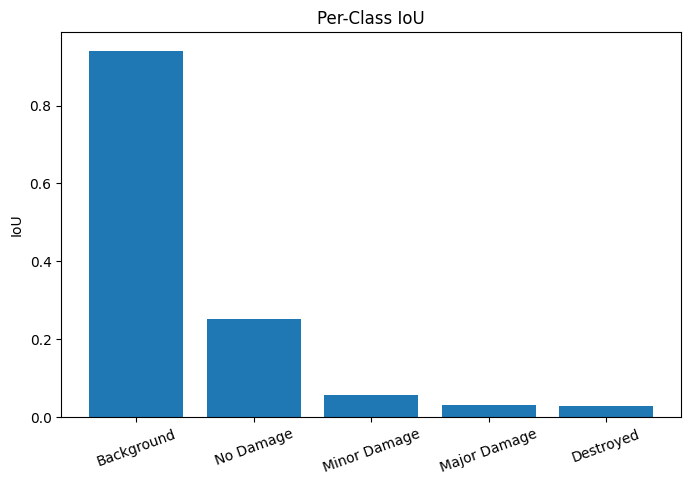

In [45]:
plt.figure(figsize=(8,5))

plt.bar(
    metrics_df["Class Name"],
    metrics_df["IoU"]
)

plt.title(
    "Per-Class IoU"
)

plt.ylabel("IoU")

plt.xticks(rotation=20)

plt.show()

## Dice Visualization

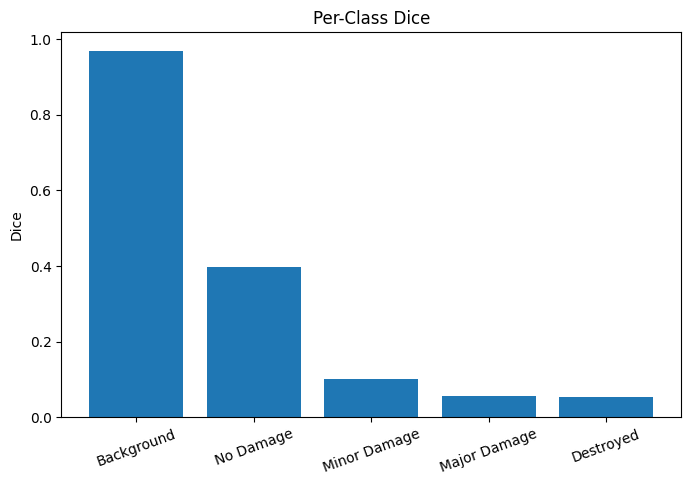

In [46]:
plt.figure(figsize=(8,5))

plt.bar(
    metrics_df["Class Name"],
    metrics_df["Dice"]
)

plt.title(
    "Per-Class Dice"
)

plt.ylabel("Dice")

plt.xticks(rotation=20)

plt.show()

## Training Curves

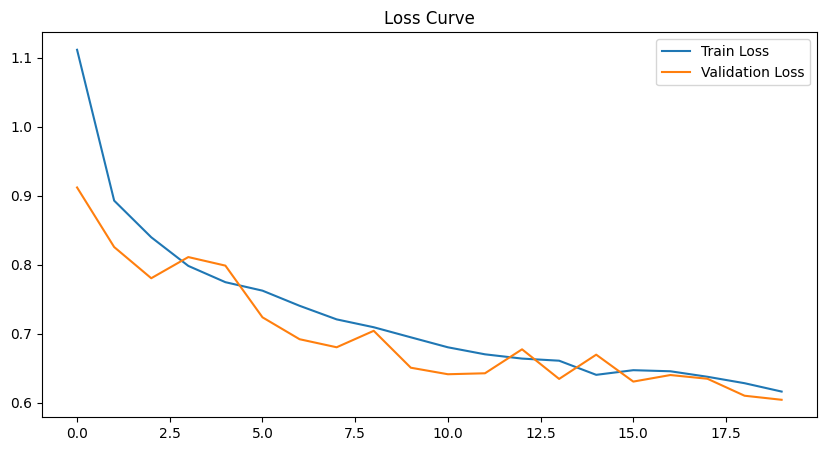

In [47]:
plt.figure(figsize=(10,5))

plt.plot(
    history["train_loss"],
    label="Train Loss"
)

plt.plot(
    history["val_loss"],
    label="Validation Loss"
)

plt.legend()

plt.title(
    "Loss Curve"
)

plt.show()

## IoU Curve

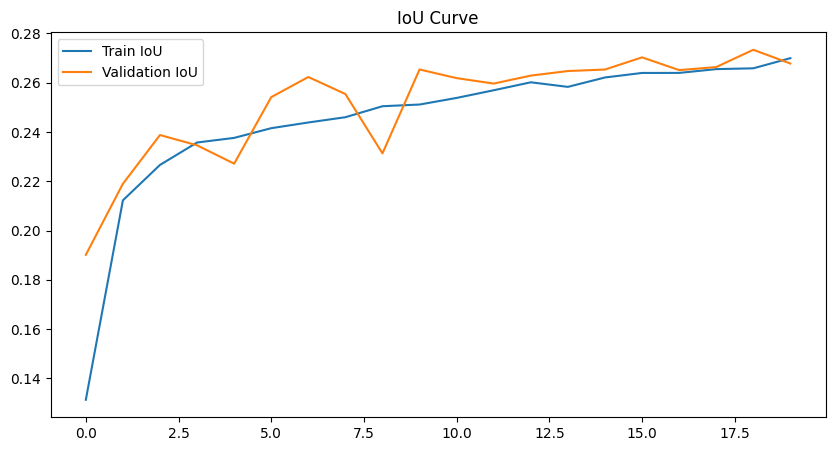

In [48]:
plt.figure(figsize=(10,5))

plt.plot(
    history["train_iou"],
    label="Train IoU"
)

plt.plot(
    history["val_iou"],
    label="Validation IoU"
)

plt.legend()

plt.title(
    "IoU Curve"
)

plt.show()

## Dice Curve

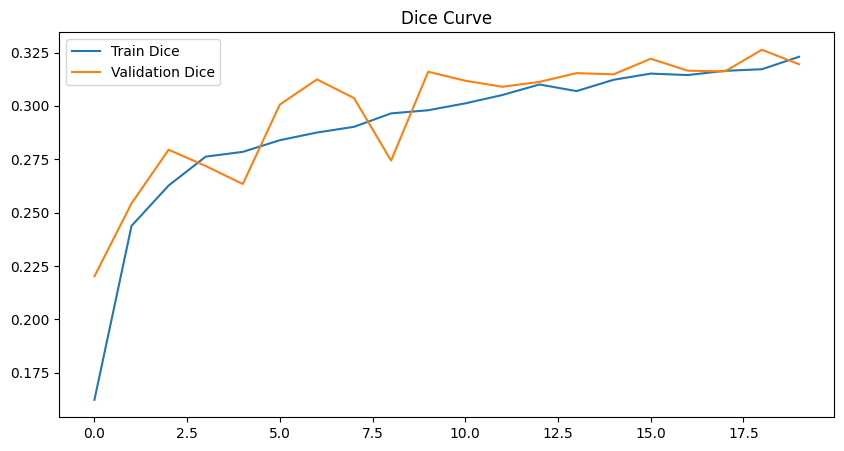

In [49]:
plt.figure(figsize=(10,5))

plt.plot(
    history["train_dice"],
    label="Train Dice"
)

plt.plot(
    history["val_dice"],
    label="Validation Dice"
)

plt.legend()

plt.title(
    "Dice Curve"
)

plt.show()

## Prediction Visualization

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.7754089..2.1632845].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.6555356..2.2317834].


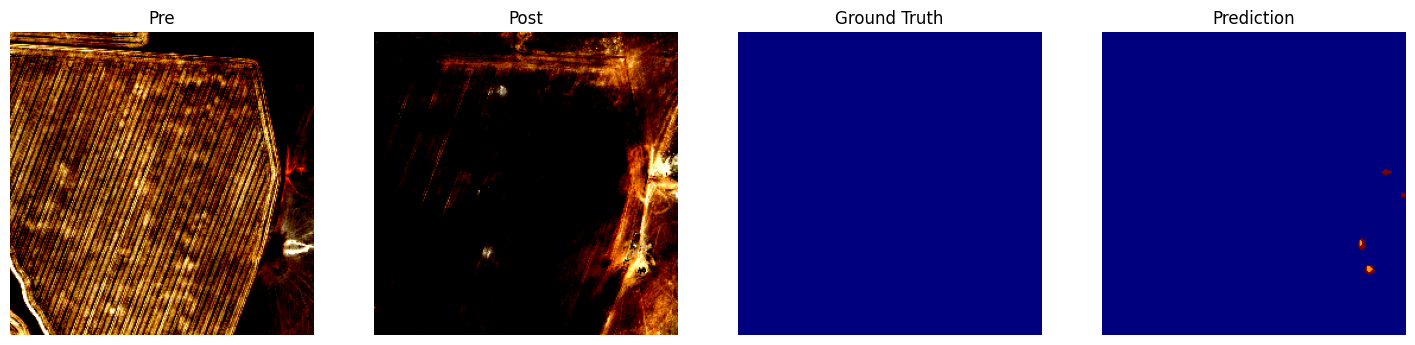

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9637811..2.1804092].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9466563..2.1632845].


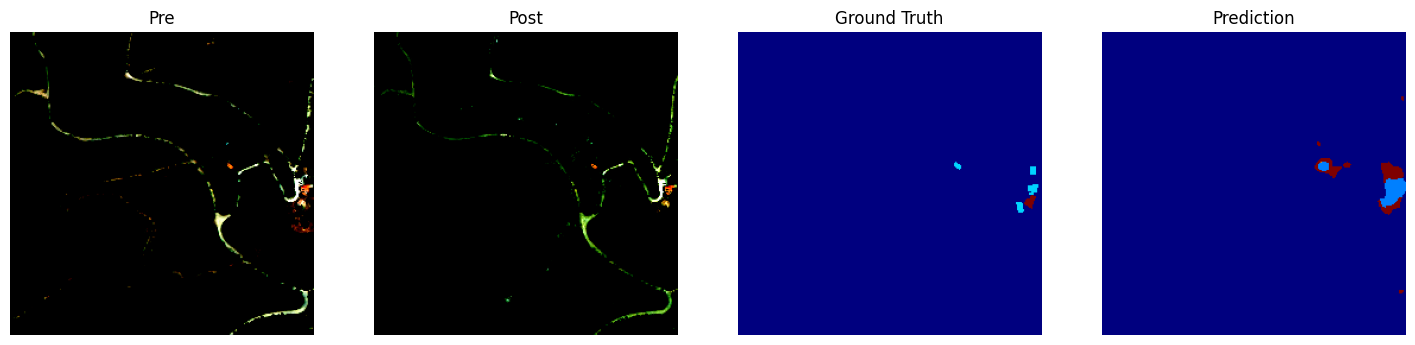

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9124069..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8439078..2.2489083].


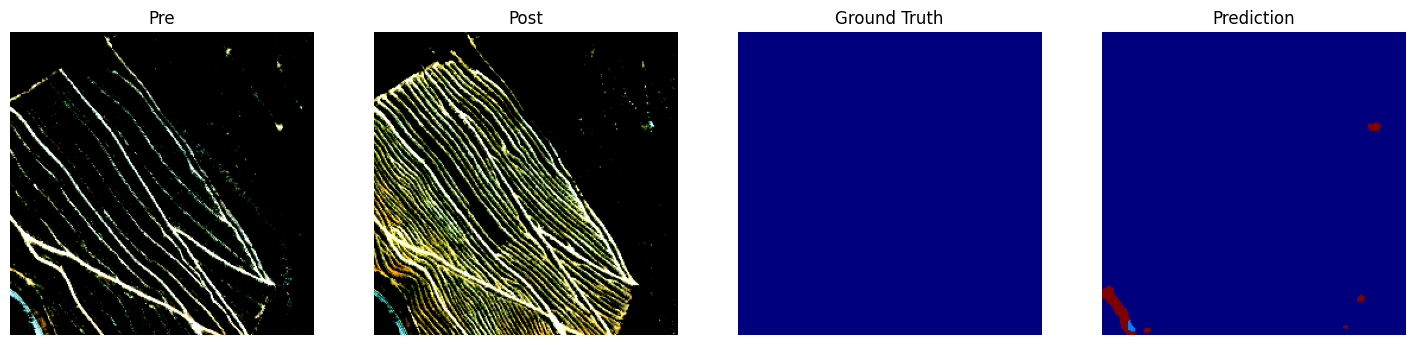

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.9809059..2.2489083].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-1.8267832..2.2489083].


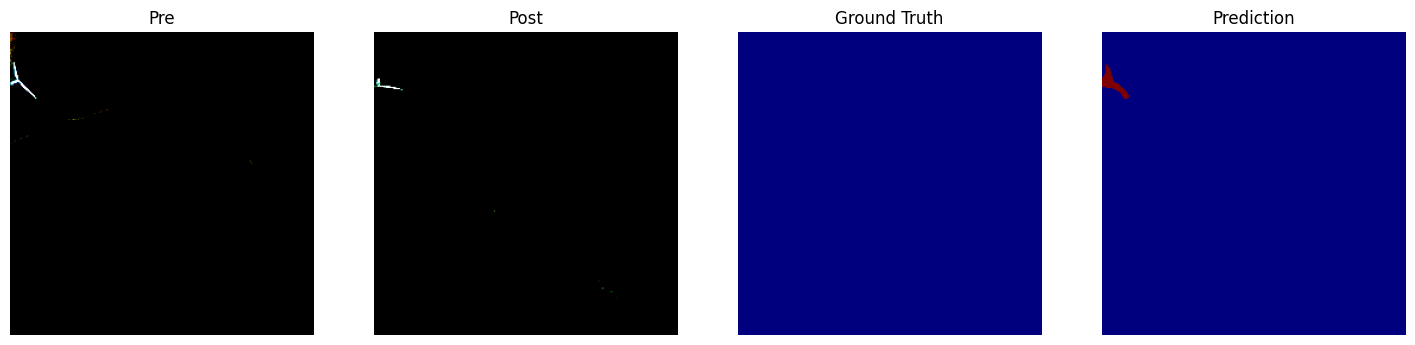

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.8207893].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-2.117904..1.4782943].


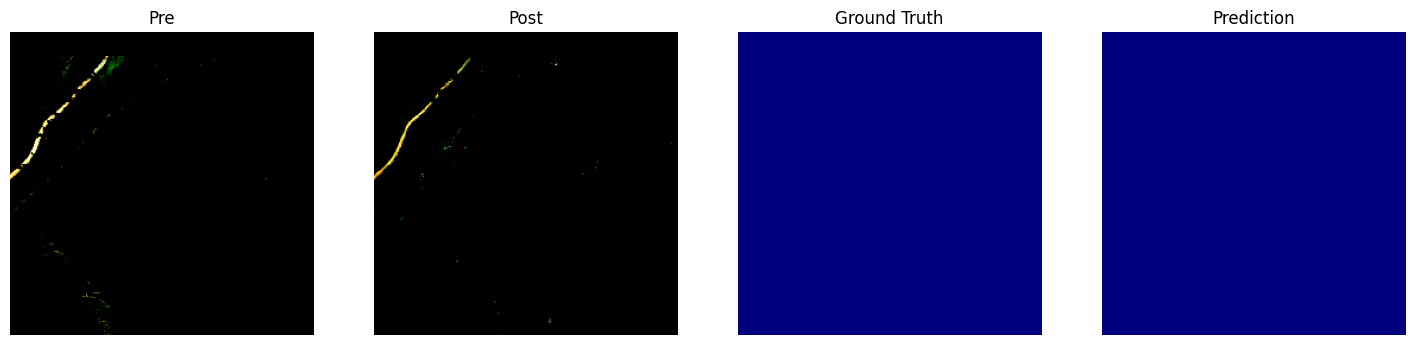

In [50]:
num_samples = 5

model.eval()

for _ in range(num_samples):

    idx = np.random.randint(
        0,
        len(test_dataset)
    )

    image, mask = (
        test_dataset[idx]
    )

    with torch.no_grad():

        pred = model(
            image.unsqueeze(0)
            .to(DEVICE)
        )

    pred = torch.argmax(
        pred,
        dim=1
    )

    pred = (
        pred.squeeze()
        .cpu()
        .numpy()
    )

    pre_img = (
        image[:3]
        .permute(1,2,0)
        .numpy()
    )

    post_img = (
        image[3:]
        .permute(1,2,0)
        .numpy()
    )

    gt_mask = mask.numpy()

    plt.figure(
        figsize=(18,4)
    )

    plt.subplot(1,4,1)
    plt.imshow(pre_img)
    plt.title("Pre")
    plt.axis("off")

    plt.subplot(1,4,2)
    plt.imshow(post_img)
    plt.title("Post")
    plt.axis("off")

    plt.subplot(1,4,3)
    plt.imshow(
        gt_mask,
        cmap="jet"
    )
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1,4,4)
    plt.imshow(
        pred,
        cmap="jet"
    )
    plt.title("Prediction")
    plt.axis("off")

    plt.show()

## Saving Metrics

In [51]:
metrics_df.to_csv(
    "test_metrics.csv",
    index=False
)

print(
    "Saved: test_metrics.csv"
)

Saved: test_metrics.csv
